In [57]:
import math

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Utils

In [58]:
def plot_graficos_de_teste(df_ablation):
    testes = df_ablation.index.tolist()
    f1_scores = df_ablation['f1-score']
    flowmiagan_auc = df_ablation['flowmiagan_auc']
    dcr_auc = df_ablation['dcr_auc']
    domias_auc = df_ablation['domias_auc']

    columns_per_row = 5

    total_rows = math.ceil(len(testes)/columns_per_row)

    fig, ax = plt.subplots(figsize=(10,5*total_rows), ncols=1, nrows= total_rows)

    largura = 0.18
    espaco = 0.03

    for i in range(total_rows):
        start = i*columns_per_row
        end = start + columns_per_row

        curr_testes = testes[start: end]
        curr_f1_scores = f1_scores[start: end]
        curr_dcr_auc = dcr_auc[start: end]
        curr_flowmiagan_auc = flowmiagan_auc[start:end]
        curr_domias_auc = domias_auc[start:end]

        indices = list(range(len(curr_testes)))
        ax[i].bar([x - largura - espaco for x in indices], curr_f1_scores, largura, label='F1-Score', color='green')
        
        b2 = ax[i].bar(indices, curr_dcr_auc, largura, label='DCR AUC', color='red')
        b3 = ax[i].bar([x + largura + espaco for x in indices], curr_domias_auc, largura, label='Domias AUC', color='red', hatch='///')
        b4 = ax[i].bar([x + 2*largura + 2*espaco for x in indices], curr_flowmiagan_auc, largura, label='Flowmiagan AUC', color='red', hatch='++')

        ax[i].set_xticks(indices)

        def parametros_em_label(test_idx):
            row = df_ablation.loc[test_idx]
            answer = f'teste: {test_idx}\n'
            answer += f'n_iter: {int(row['n_iter'])}\n'
            answer += f'batch_size: {int(row['batch_size'])}\n'
            answer += f'n_units_hidden: {int(row['n_units_hidden'])}\n'
            return answer

        ax[i].set_xticklabels([f'{parametros_em_label(x)}' for x in curr_testes])

        ax[i].set_xlabel('Testes')
        ax[i].set_ylabel('Resultado')

        ax[i].legend(bbox_to_anchor=(-0.05, 1), loc='upper right')
        

    plt.tight_layout()


## Resultado Anterior

In [59]:
df_ablation_v1 = pd.read_csv('ablation_v1/cidds/results/ablation.csv')
df_ablation_v1.set_index('test_idx', inplace=True)
df_ablation_v1.head()

,n_iter,batch_size,n_units_hidden,flowmiagan_auc,domias_auc,dcr_auc,accuracy,precision,recall,f1-score
test_idx,,,,,,,,,,
1,50,50,32,0.647546,0.789854,0.555769,0.459733,0.424555,0.470480,0.370556
2,50,50,64,0.844536,0.905167,0.940850,0.991800,0.991918,0.991692,0.991792
3,50,50,128,0.840618,0.924410,0.943813,0.994267,0.994444,0.994126,0.994261
4,50,100,32,0.734118,0.846472,0.545236,0.646933,0.713195,0.638886,0.609610
5,50,100,64,0.654675,0.883320,0.926600,0.977000,0.976947,0.977301,0.976994


In [60]:
df_ablation_v1['media_auc'] = (df_ablation_v1['flowmiagan_auc'] + df_ablation_v1['domias_auc'] + df_ablation_v1['dcr_auc'])/3
df_ablation_v1['f1_X_auc'] = df_ablation_v1['f1-score'] - df_ablation_v1['media_auc']

df_ablation_v1 = df_ablation_v1.sort_values(by=['n_units_hidden', 'batch_size', 'n_iter'])
df_ablation_v1.head()

,n_iter,batch_size,n_units_hidden,flowmiagan_auc,domias_auc,dcr_auc,accuracy,precision,recall,f1-score,media_auc,f1_X_auc
test_idx,,,,,,,,,,,,
1,50,50,32,0.647546,0.789854,0.555769,0.459733,0.424555,0.470480,0.370556,0.664390,-0.293834
13,100,50,32,0.382098,0.915123,0.906177,0.958800,0.960833,0.958003,0.958673,0.734466,0.224208
25,150,50,32,0.784031,0.885274,0.895778,0.997667,0.997721,0.997615,0.997665,0.855028,0.142637
37,200,50,32,0.837482,0.928460,0.856609,0.996867,0.996822,0.996914,0.996865,0.874184,0.122681
4,50,100,32,0.734118,0.846472,0.545236,0.646933,0.713195,0.638886,0.609610,0.708609,-0.098999


### Valores de F1-Score, AUC do Domias, AUC do DCR e AUC do Flowmiagan para cada teste

In [ ]:
plot_graficos_de_teste(df_ablation_v1)

## Resultado Novo

In [62]:
df_ablation = pd.read_csv('ablation/cidds/results/ablation.csv')
df_ablation.set_index('test_idx', inplace=True)
df_ablation.head()

,n_iter,batch_size,n_units_hidden,flowmiagan_auc,domias_auc,dcr_auc,accuracy,precision,recall,f1-score
test_idx,,,,,,,,,,
1,50,50,32,0.489130,0.362623,0.543846,0.513800,0.256900,0.500000,0.339411
2,50,50,64,0.853011,0.899003,0.914043,0.993867,0.994062,0.993715,0.993860
3,50,50,128,0.782760,0.904685,0.893187,0.993467,0.993661,0.993314,0.993460
4,50,100,32,0.620421,0.743334,0.560913,0.515200,0.748083,0.528214,0.387269
5,50,100,64,0.644094,0.897002,0.878373,0.897533,0.912510,0.894964,0.896091


In [63]:
df_ablation['media_auc'] = (df_ablation['flowmiagan_auc'] + df_ablation['domias_auc'] + df_ablation['dcr_auc'])/3
df_ablation['f1_X_auc'] = df_ablation['f1-score'] - df_ablation['media_auc']

df_ablation = df_ablation.sort_values(by=['n_units_hidden', 'batch_size', 'n_iter'])
df_ablation.head()

,n_iter,batch_size,n_units_hidden,flowmiagan_auc,domias_auc,dcr_auc,accuracy,precision,recall,f1-score,media_auc,f1_X_auc
test_idx,,,,,,,,,,,,
1,50,50,32,0.489130,0.362623,0.543846,0.5138,0.256900,0.500000,0.339411,0.465199,-0.125789
13,100,50,32,0.705086,0.758946,0.874110,0.9878,0.987766,0.987818,0.987791,0.779381,0.208411
25,150,50,32,0.877865,0.915203,0.931232,0.9574,0.959044,0.958393,0.957396,0.908100,0.049296
37,200,50,32,0.852054,0.924709,0.928362,0.9880,0.988239,0.987814,0.987986,0.901708,0.086278
4,50,100,32,0.620421,0.743334,0.560913,0.5152,0.748083,0.528214,0.387269,0.641556,-0.254287


### Valores de F1-Score, AUC do Domias, AUC do DCR e AUC do Flowmiagan para cada teste

In [ ]:
plot_graficos_de_teste(df_ablation)

In [70]:
heatmap = df_ablation[df_ablation['n_units_hidden'] == 32][['n_iter', 'batch_size', 'dcr_auc']].pivot(index='n_iter', columns='batch_size', values='dcr_auc')
heatmap

batch_size,50,100,500,1000
n_iter,,,,
50,0.543846,0.560913,0.422850,0.736731
100,0.874110,0.821010,0.461252,0.658317
150,0.931232,0.723726,0.575056,0.725892
200,0.928362,0.936749,0.437183,0.834077


In [ ]:
heatmap = df_ablation[df_ablation['n_units_hidden'] == 32][['n_iter', 'batch_size', 'domias_auc']].pivot(index='n_iter', columns='batch_size', values='domias_auc')
heatmap

batch_size,50,100,500,1000
n_iter,,,,
50,0.362623,0.743334,0.668277,0.779870
100,0.758946,0.788060,0.401828,0.891659
150,0.915203,0.496303,0.581147,0.904072
200,0.924709,0.924895,0.427893,0.690609


In [76]:
heatmap = df_ablation[df_ablation['n_units_hidden'] == 32][['n_iter', 'batch_size', 'flowmiagan_auc']].pivot(index='n_iter', columns='batch_size', values='flowmiagan_auc')
heatmap

batch_size,50,100,500,1000
n_iter,,,,
50,0.489130,0.620421,0.640573,0.551146
100,0.705086,0.499658,0.618012,0.616607
150,0.877865,0.513120,0.389915,0.638133
200,0.852054,0.873773,0.249097,0.590562


In [101]:
def grid_search_matrix(df, fixed_column: str, x_column: str, y_column: str, value_column: str):
    all_fixed_values = pd.unique(df[fixed_column])

    total_columns = len(all_fixed_values)

    fig, ax = plt.subplots(figsize=(7*total_columns,5), ncols=total_columns, nrows= 1)

    for i, fixed_in in enumerate(all_fixed_values):
        result_heatmap = df[df[fixed_column] == fixed_in][[x_column, y_column, value_column]].pivot(index=y_column, columns=x_column, values=value_column)

        sns.heatmap(result_heatmap, annot=True, cmap="YlGnBu", ax=ax[i], vmin=0, vmax=1)
        ax[i].set_xlabel(x_column)
        ax[i].set_ylabel(y_column)
        ax[i].set_title(f"{value_column} - {fixed_column}: {fixed_in}")
        
    plt.show()

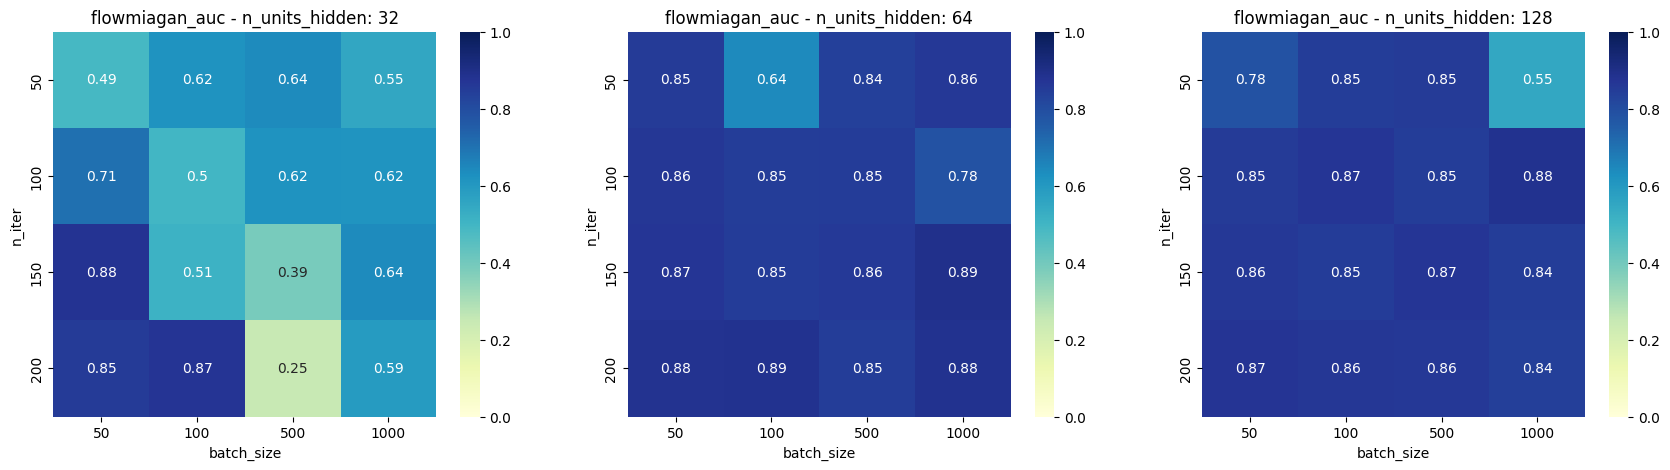

In [102]:
grid_search_matrix(df_ablation, 'n_units_hidden', 'batch_size', 'n_iter', 'flowmiagan_auc')

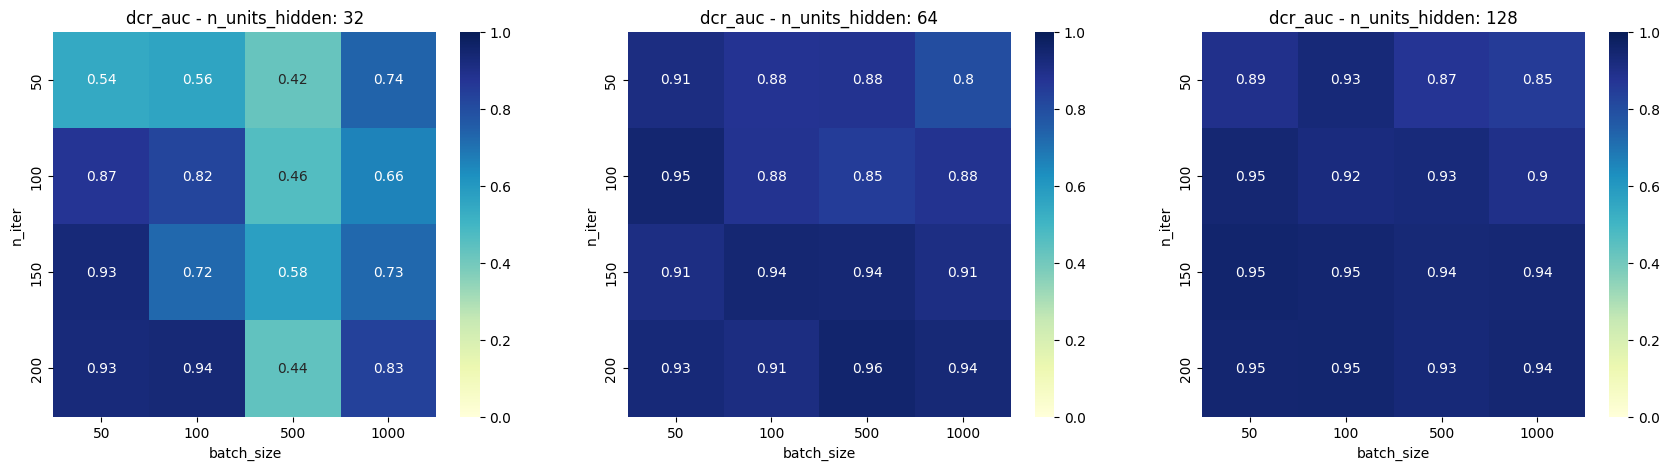

In [103]:
grid_search_matrix(df_ablation, 'n_units_hidden', 'batch_size', 'n_iter', 'dcr_auc')

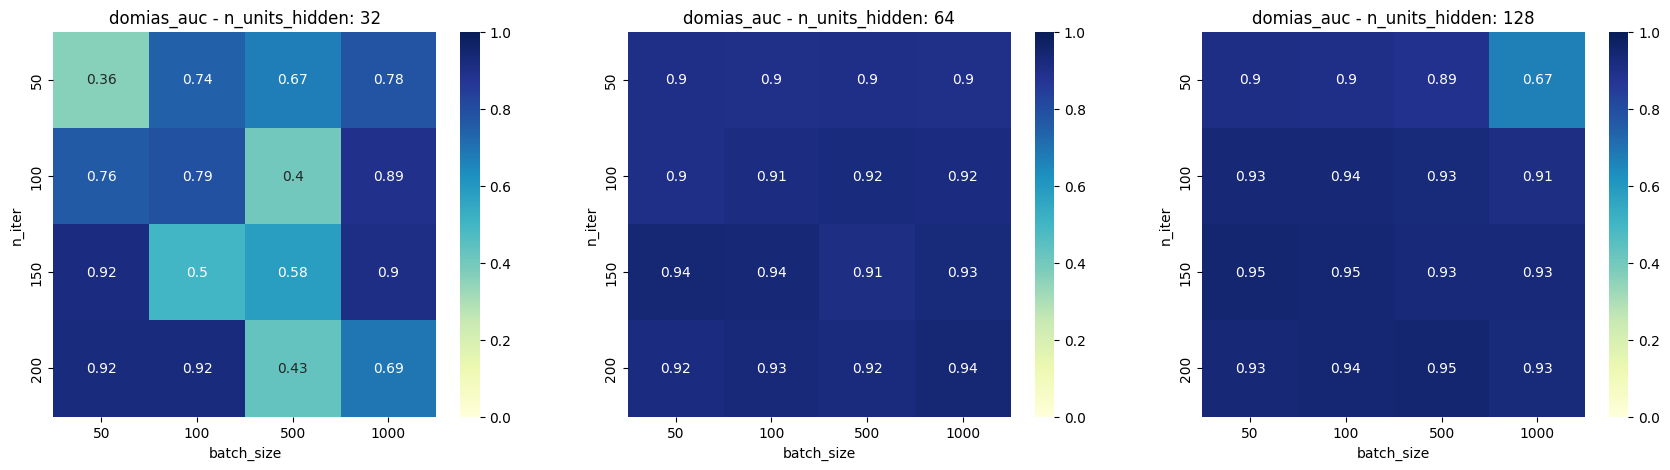

In [104]:
grid_search_matrix(df_ablation, 'n_units_hidden', 'batch_size', 'n_iter', 'domias_auc')